In [12]:
# ----------- Load Libraries -----------
library(phyloseq)
library(tidyr)
library(microbiome)
library(dplyr)
library(broom)
library(openxlsx)
library(tibble)
library(emmeans)
library(ggpubr)
library(vegan)
library(patchwork)
library(compositions)
library(ape)
library(lmerTest)
library(writexl)


Welcome to emmeans.
Caution: You lose important information if you filter this package's results.
See '? untidy'

Loading required package: permute


Attaching package: ‘vegan’


The following object is masked from ‘package:microbiome’:

    diversity


Welcome to compositions, a package for compositional data analysis.
Find an intro with "? compositions"



Attaching package: ‘compositions’


The following objects are masked from ‘package:stats’:

    anova, cor, cov, dist, var


The following object is masked from ‘package:graphics’:

    segments


The following objects are masked from ‘package:base’:

    %*%, norm, scale, scale.default



Attaching package: ‘ape’


The following object is masked from ‘package:compositions’:

    balance


The following object is masked from ‘package:ggpubr’:

    rotate


The following object is masked from ‘package:dplyr’:

    where


Loading required package: lme4

Warning message:
“package ‘lme4’ was built under R version 4.4.3”
Loading requir

In [1]:
# -----------------------------
# Load Required Packages
# -----------------------------
library(phyloseq)
library(MBECS)

# -----------------------------
# Step 1: Load Cleaned Phyloseq Object
# -----------------------------
ps <- readRDS("/scratch/negishi/ldas/COW_INFLAMMATION/DADA2_inputs/GP_ps.st.decontam.cleaned.nomock.rds")

# -----------------------------
# Step 2: Extract and Prepare Metadata and Counts
# -----------------------------
raw <- as(otu_table(ps), "matrix")
if (taxa_are_rows(ps)) {
  raw <- t(raw)
}

meta <- as(sample_data(ps), "data.frame")

# Assign group = Fibrinogen
meta$group <- factor(meta$Fibrinogen_InflamStat)  # ✅ Group = Fibrinogen
meta$batch <- factor(as.Date(meta$ExtractionDate, format = "%m/%d/%Y"))
meta$replicate <- factor(meta$Cow_ID)

# Other covariates
meta$BCS <- factor(meta$BCS)
meta$DIM_Collected <- factor(meta$DIM_Collected)
meta$Parity <- factor(meta$Parity)
meta$Haptoglobin_InflamStat <- factor(meta$Haptoglobin_InflamStat)
meta$sID <- rownames(meta)

# -----------------------------
# Step 3: Remove Samples with Missing Values
# -----------------------------
required_vars <- c("group", "batch", "replicate", "BCS", "DIM_Collected", "Parity", "Haptoglobin_InflamStat")
meta <- meta[complete.cases(meta[, required_vars]), ]

# Align raw with cleaned metadata
shared_samples <- intersect(rownames(raw), rownames(meta))
raw <- raw[shared_samples, ]
meta <- meta[shared_samples, ]
raw <- raw[order(rownames(raw)), ]
meta <- meta[order(rownames(meta)), ]

# -----------------------------
# Step 4: Create and Normalize MBECS Input Object
# -----------------------------
dummy.ps <- list(
  raw = raw,
  meta = meta
)

mbec.obj <- mbecProcessInput(dummy.ps, required.col = c("group", "batch", "replicate"))

# Optional: Apply TSS only (no CLR)
mbec.obj <- mbecTransform(mbec.obj, method = "tss")

# -----------------------------
# Step 5: Save mbec.obj Before CLR
# -----------------------------
saveRDS(mbec.obj, "/scratch/negishi/ldas/COW_INFLAMMATION/DADA2_outputs/mbec_obj_tss_only_Fibrinogen.rds")


Set tss-transformed counts.



In [2]:
# -----------------------------
# Load Required Packages
# -----------------------------
library(phyloseq)
library(microbiome)   # for evenness()
library(dplyr)

# -----------------------------
# Load MBEC-Corrected Phyloseq Object
# -----------------------------
ps <- readRDS("/scratch/negishi/ldas/COW_INFLAMMATION/DADA2_outputs/mbec_obj_tss_only_Fibrinogen.rds")

# -----------------------------
# Estimate Alpha Diversity
# -----------------------------
alpha_df <- suppressWarnings(estimate_richness(ps, measures = c("Observed", "Shannon", "Simpson")))
alpha_df$Evenness <- evenness(ps, index = "pielou")$pielou

# -----------------------------
# Extract Metadata and Format
# -----------------------------
meta <- data.frame(sample_data(ps))
meta$ExtractionDate <- as.Date(meta$ExtractionDate, format = "%m/%d/%Y")
meta$ExtractionDate_numeric <- as.numeric(meta$ExtractionDate - min(meta$ExtractionDate, na.rm = TRUE))
meta$Cow_ID <- as.factor(meta$Cow_ID)

# -----------------------------
# Merge Metadata with Alpha Diversity
# -----------------------------
vars <- c("BCS", "Parity", "DIM_Collected", "Fibrinogen_InflamStat", "Haptoglobin_InflamStat", "ExtractionDate_numeric", "Cow_ID")
alpha_df <- cbind(alpha_df, meta[, vars])

# -----------------------------
# Clean and Format for Modeling
# -----------------------------
metrics <- c("Observed", "Shannon", "Simpson", "Evenness")
alpha_df <- alpha_df[complete.cases(alpha_df[, c(metrics, vars)]), ]

# Format variables as factors (if not already)
alpha_df$Parity <- as.factor(alpha_df$Parity)
alpha_df$BCS <- as.factor(alpha_df$BCS)
alpha_df$Fibrinogen_InflamStat <- factor(alpha_df$Fibrinogen_InflamStat, levels = c("Normal", "Elevated"))
alpha_df$Haptoglobin_InflamStat <- factor(alpha_df$Haptoglobin_InflamStat, levels = c("Normal", "Elevated"))
alpha_df$Cow_ID <- as.factor(alpha_df$Cow_ID)

# -----------------------------
# Optional: View summary
# -----------------------------
summary(alpha_df)


Loading required package: ggplot2


microbiome R package (microbiome.github.com)
    


 Copyright (C) 2011-2022 Leo Lahti, 
    Sudarshan Shetty et al. <microbiome.github.io>



Attaching package: ‘microbiome’


The following object is masked from ‘package:ggplot2’:

    alpha


The following object is masked from ‘package:base’:

    transform



Attaching package: ‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union




    Observed        Shannon         Simpson          Evenness           BCS    
 Min.   : 71.0   Min.   :3.680   Min.   :0.9314   Min.   :0.8458   3.5    :36  
 1st Qu.:117.0   1st Qu.:4.487   1st Qu.:0.9820   1st Qu.:0.9495   3.75   :34  
 Median :130.0   Median :4.720   Median :0.9885   Median :0.9694   3.25   :22  
 Mean   :127.3   Mean   :4.646   Mean   :0.9840   Mean   :0.9598   2.75   :16  
 3rd Qu.:139.0   3rd Qu.:4.824   3rd Qu.:0.9906   3rd Qu.:0.9801   4      :16  
 Max.   :162.0   Max.   :5.044   Max.   :0.9931   Max.   :0.9924   3      :12  
                                                                   (Other): 6  
 Parity DIM_Collected Fibrinogen_InflamStat Haptoglobin_InflamStat
 1:34   1:71          Normal  :52           Normal  :115          
 2:52   3:71          Elevated:90           Elevated: 27          
 3:26                                                             
 4:18                                                             
 5: 4                    

In [18]:
# ----------- Define Paths -----------
path.figures <- "/scratch/negishi/ldas/COW_INFLAMMATION/Figures"
path.stat <- "/scratch/negishi/ldas/COW_INFLAMMATION/DADA2_outputs/stats"
tree <- readRDS("/scratch/negishi/ldas/COW_INFLAMMATION/DADA2_outputs/phy_tree_gp_decontam_rooted.rds")

In [8]:
# ----------- Multivariate Linear Models -----------
lm_results <- lapply(metrics, function(metric) {
  model <- lm(
    formula = as.formula(paste(metric, "~ Fibrinogen_InflamStat + Haptoglobin_InflamStat + Parity + BCS + DIM_Collected + ExtractionDate_numeric + Cow_ID")),
    data = alpha_df
  )
  tidy_model <- tidy(model)
  tidy_model$Metric <- metric
  tidy_model$R2 <- summary(model)$r.squared
  tidy_model
})

# Combine into single data frame
lm_df <- bind_rows(lm_results)

# ----------- Adjust P-values (FDR) -----------
lm_df <- lm_df %>%
  group_by(Metric) %>%
  mutate(FDR_p = p.adjust(p.value, method = "fdr")) %>%
  ungroup()

# ----------- Effect Size Summaries -----------
summary_list <- list()
for (var in vars) {
  if (is.numeric(alpha_df[[var]]) || (is.factor(alpha_df[[var]]) && nlevels(alpha_df[[var]]) > 10)) next
  for (metric in metrics) {
    medians <- tapply(alpha_df[[metric]], alpha_df[[var]], median)
    summary_list[[paste(metric, var, sep = "_")]] <- medians
  }
}
effect_sizes <- bind_rows(summary_list, .id = "Metric_Variable")


In [13]:
# ----------- Define Output File Path -----------
Alpha_multivariate <- file.path(path.stat, "Alpha_diversity_multivariate_Fibrinogen.xlsx")

# ----------- Export to Excel -----------
write.xlsx(
  list(
    "Linear_Model_Stats" = lm_df,
    "Effect_Size_Summaries" = effect_sizes
  ),
  file = Alpha_multivariate,
  rowNames = FALSE
)


In [14]:

# ----------- Univariate Linear Models -----------
lm_uni_results <- list()

for (metric in metrics) {
  for (var in vars) {
    df_sub <- alpha_df[complete.cases(alpha_df[, c(metric, var)]), ]
    
    # Skip if factor has <2 levels
    if (is.factor(df_sub[[var]]) && nlevels(df_sub[[var]]) < 2) next
    
    model <- lm(as.formula(paste(metric, "~", var)), data = df_sub)
    tidy_model <- broom::tidy(model)
    tidy_model$Metric <- metric
    tidy_model$Variable <- var
    tidy_model$R2 <- summary(model)$r.squared
    
    lm_uni_results[[paste(metric, var, sep = "_")]] <- tidy_model
  }
}

lm_uni_df <- bind_rows(lm_uni_results)

# ----------- Adjust P-values (FDR) by Metric -----------
lm_uni_df <- lm_uni_df %>%
  group_by(Metric) %>%
  mutate(FDR_p = p.adjust(p.value, method = "fdr")) %>%
  ungroup()

# ----------- Effect Size Summaries -----------
summary_list_uni <- list()
for (var in vars) {
  if (is.numeric(alpha_df[[var]]) || (is.factor(alpha_df[[var]]) && nlevels(alpha_df[[var]]) > 10)) next
  for (metric in metrics) {
    medians <- tapply(alpha_df[[metric]], alpha_df[[var]], median)
    summary_list_uni[[paste(metric, var, sep = "_")]] <- medians
  }
}
effect_sizes_uni <- bind_rows(summary_list_uni, .id = "Metric_Variable")


In [16]:
# ----------- Define Output File Path for Univariate Results -----------
Alpha_univariate <- file.path(path.stat, "Alpha_diversity_univariate_Fibrinogen.xlsx")

# ----------- Export Univariate Results to Excel -----------
write.xlsx(
  list(
    "Linear_Model_Stats" = lm_uni_df,
    "Effect_Size_Summaries" = effect_sizes_uni
  ),
  file = Alpha_univariate,
  rowNames = FALSE
)


In [26]:
# Load phyloseq object and rooted tree
ps <- readRDS("/scratch/negishi/ldas/COW_INFLAMMATION/DADA2_outputs/ps_clr_mbec_Fibrinogen.rds")

tree <- readRDS("/scratch/negishi/ldas/COW_INFLAMMATION/DADA2_outputs/phy_tree_gp_decontam_rooted.rds")

# Rename ASVs (important for tree matching)
asv_seqs <- taxa_names(ps_beta)
names(asv_seqs) <- paste0("ASV", seq_along(asv_seqs))
taxa_names(ps_beta) <- names(asv_seqs)
tree$tip.label <- names(asv_seqs)

# Attach tree AFTER pruning and ASV renaming
phy_tree(ps_beta) <- tree


In [28]:
library(lme4)
library(broom.mixed)
library(dplyr)
library(writexl)
library(readr)

# Define covariates and alpha diversity metrics
covariates <- c("Parity", "BCS", "DIM_Collected_z", "ExtractionDate_numeric_z")
diversity_metrics <- c("Observed", "Shannon", "Simpson", "Evenness")

# Store results
diversity_assoc <- list()
problem_diversity_models <- c()

for (metric in diversity_metrics) {
  for (covar in covariates) {
    formula_str <- as.formula(paste(metric, "~", covar, "+ (1 | Cow_ID)"))
    
    tryCatch({
      model <- suppressWarnings(
        lmer(formula_str, data = alpha_df, control = lmerControl(optimizer = "bobyqa", optCtrl = list(maxfun = 2e5)))
      )
      tidy_model <- suppressWarnings(broom.mixed::tidy(model))
      tidy_model$is_singular <- isSingular(model, tol = 1e-4)
      tidy_model$diversity_metric <- metric
      tidy_model$covariate <- covar
      diversity_assoc[[paste(metric, covar, sep = "_")]] <- tidy_model
    }, error = function(e) {
      problem_diversity_models <<- c(problem_diversity_models, paste(metric, covar, sep = "_"))
    })
  }
}

# Combine model results
diversity_df <- bind_rows(diversity_assoc) %>%
  filter(effect == "fixed", term != "(Intercept)") %>%
  select(diversity_metric, covariate, term, estimate, std.error, statistic, p.value, is_singular)

# Apply FDR correction
diversity_df <- diversity_df %>%
  group_by(diversity_metric) %>%
  mutate(FDR_p = p.adjust(p.value, method = "fdr")) %>%
  ungroup()

# Save output
write_csv(diversity_df, file.path(path.stat, "AlphaDiversity_MixedModels_Fibrinogen.csv"))
write.xlsx(diversity_df, file.path(path.stat, "AlphaDiversity_MixedModels_Fibrinogen.xlsx"))


boundary (singular) fit: see help('isSingular')

boundary (singular) fit: see help('isSingular')



In [29]:
# ----------- Load Required Libraries -----------
library(broom)
library(dplyr)
library(readr)
library(writexl)

# ----------- Define Variables -----------
covariates <- c("Parity", "BCS", "DIM_Collected_z", "ExtractionDate_numeric_z")
inflammation_vars <- c("Fibrinogen_InflamStat", "Haptoglobin_InflamStat")

# ----------- Initialize Storage -----------
inflam_assoc <- list()
problem_inflam_models <- c()

# ----------- Loop Through Each Combination -----------
for (inflamm in inflammation_vars) {
  for (covar in covariates) {
    formula_str <- as.formula(paste(inflamm, "~", covar))
    
    tryCatch({
      model <- glm(formula_str,
                   data = alpha_df,
                   family = binomial)
      
      tidy_model <- broom::tidy(model)
      tidy_model$inflammation <- inflamm
      tidy_model$covariate <- covar
      inflam_assoc[[paste(inflamm, covar, sep = "_")]] <- tidy_model
      
    }, error = function(e) {
      problem_inflam_models <<- c(problem_inflam_models, paste(inflamm, covar, sep = "_"))
    })
  }
}

# ----------- Combine and Save Results -----------
inflam_df <- bind_rows(inflam_assoc) %>%
  filter(term != "(Intercept)") %>%
  select(inflammation, covariate, term, estimate, std.error, statistic, p.value)

# ----------- Apply FDR Correction -----------
inflam_df <- inflam_df %>%
  group_by(inflammation) %>%
  mutate(FDR_p = p.adjust(p.value, method = "fdr")) %>%
  ungroup()

# ----------- Save Output -----------
write_csv(inflam_df, file.path(path.stat, "Inflammation_Fibrinogen.csv"))
write.xlsx(inflam_df, file.path(path.stat, "Inflammation_Fibrinogen.xlsx"))


In [30]:
# ----------- Load Inflammation and Diversity Results -----------
inflam_df <- read_csv(file.path(path.stat, "Inflammation_Fibrinogen.csv"))  
diversity_df <- read_csv(file.path(path.stat, "AlphaDiversity_MixedModels_Fibrinogen.csv"))  

# ----------- Filter significant terms (e.g., p < 0.05 or FDR_p < 0.1) -----------
sig_inflam <- inflam_df %>%
  filter(p.value < 0.05)

sig_diversity <- diversity_df %>%
  filter(p.value < 0.05)

# ----------- Join on covariate + term to identify shared confounders -----------
confounders <- inner_join(sig_inflam, sig_diversity, by = c("covariate", "term"))

# ----------- Select clean columns -----------
confounders_cleaned <- confounders %>%
  select(covariate, term, inflammation, diversity_metric,
         estimate_inflam = estimate.x, p_inflam = p.value.x, FDR_p_inflam = FDR_p.x,
         estimate_diversity = estimate.y, p_diversity = p.value.y, FDR_p_diversity = FDR_p.y)

# ----------- Save Output -----------
write.xlsx(confounders_cleaned,
           file = file.path(path.stat, "Potential_Confounders_Alpha_Diversity_Inflammation_Fibrinogen.xlsx"),
           rowNames = FALSE)


Rows: 28 Columns: 8
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr (3): inflammation, covariate, term
dbl (5): estimate, std.error, statistic, p.value, FDR_p

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.
Rows: 56 Columns: 9
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr (3): diversity_metric, covariate, term
dbl (5): estimate, std.error, statistic, p.value, FDR_p
lgl (1): is_singular

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


Warning message:
“package ‘readxl’ was built under R version 4.4.3”
boundary (singular) fit: see help('isSingular')

boundary (singular) fit: see help('isSingular')



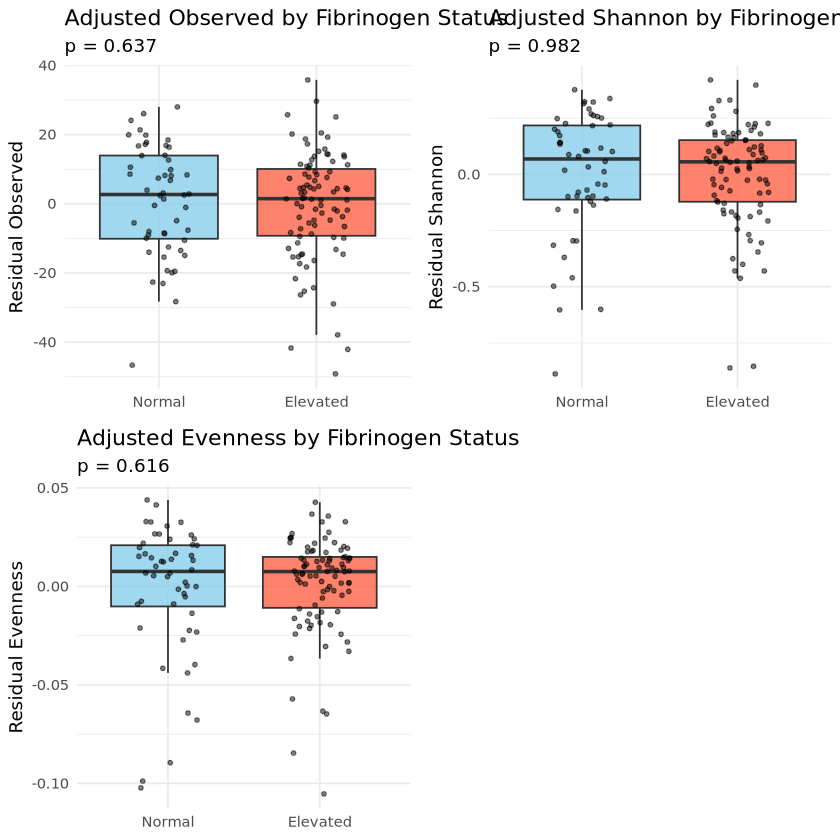

In [31]:
# ----------- Load Required Libraries -----------
library(readxl)
library(dplyr)
library(ggplot2)
library(ggpubr)
library(broom)

# ----------- Load Confounder Table -----------
conf_tbl <- read_xlsx(file.path(path.stat, "Potential_Confounders_Alpha_Diversity_Inflammation_Fibrinogen.xlsx"))

# ----------- Subset for Fibrinogen Only -----------
conf_fib <- conf_tbl %>% filter(inflammation == "Fibrinogen_InflamStat")

# ----------- Ensure Fibrinogen is a factor -----------
alpha_df$Fibrinogen_InflamStat <- factor(alpha_df$Fibrinogen_InflamStat, levels = c("Normal", "Elevated"))

# ----------- Initialize storage -----------
residual_plots_fib <- list()
t_tests_fib <- list()

# ----------- Loop Over Diversity Metrics -----------
for (metric in unique(conf_fib$diversity_metric)) {
  
  confounders <- unique(conf_fib %>% filter(diversity_metric == metric) %>% pull(covariate))
  if (length(confounders) == 0) next
  
  formula_str <- paste0(metric, " ~ ", paste(confounders, collapse = " + ") , " + (1 | Cow_ID)")
  model <- lmer(formula_str, data = alpha_df)
  
  resid_col <- paste0(metric, "_resid_fib")
  alpha_df[[resid_col]] <- resid(model)
  
  # t-test on residuals
  ttest <- t.test(alpha_df[[resid_col]] ~ alpha_df$Fibrinogen_InflamStat)
  pval <- signif(ttest$p.value, 3)
  t_tests_fib[[metric]] <- tidy(ttest)
  
  # Plot
  p <- ggplot(alpha_df, aes(x = Fibrinogen_InflamStat, y = .data[[resid_col]], fill = Fibrinogen_InflamStat)) +
    geom_boxplot(outlier.shape = NA, alpha = 0.8) +
    geom_jitter(width = 0.2, size = 1, alpha = 0.5) +
    labs(title = paste("Adjusted", metric, "by Fibrinogen Status"),
         subtitle = paste("p =", pval),
         x = NULL, y = paste("Residual", metric)) +
    scale_fill_manual(values = c("Normal" = "skyblue", "Elevated" = "tomato")) +
    theme_minimal() +
    theme(legend.position = "none")
  
  residual_plots_fib[[metric]] <- p
}

# ----------- Clean up and Save -----------
residual_plots_fib <- residual_plots_fib[!sapply(residual_plots_fib, is.null)]
p_comb_fib <- ggarrange(plotlist = residual_plots_fib, ncol = 2, nrow = ceiling(length(residual_plots_fib) / 2))

ggsave(file.path(path.figures, "AlphaDiversity_Adjusted_Fibrinogen.tiff"),
       plot = p_comb_fib, dpi = 300, width = 10, height = 8)
ggsave(file.path(path.figures, "AlphaDiversity_Adjusted_Fibrinogen.png"),
       plot = p_comb_fib, dpi = 300, width = 10, height = 8)

# Save T-test summary
t_test_df_fib <- bind_rows(t_tests_fib, .id = "Metric")
write.csv(t_test_df_fib, file = file.path(path.stat, "AlphaDiversity_Adjusted_Fibrinogen_Ttest.csv"), row.names = FALSE)
print(p_comb_fib)

In [35]:
library(lme4)
library(performance)  # for r2()
library(dplyr)
library(broom)

metrics <- c("Observed", "Shannon", "Evenness")
confounder_map <- split(conf_fib$covariate, conf_fib$diversity_metric)

summary_table <- list()

for (metric in metrics) {
  confounders <- confounder_map[[metric]]
  if (is.null(confounders)) next
  
  # Build formula
  formula_str <- paste0(metric, " ~ ", paste(confounders, collapse = " + "), " + (1|Cow_ID)")
  model <- lmer(as.formula(formula_str), data = alpha_df)
  
  # Residuals and t-test
  resid_col <- paste0(metric, "_resid_fib")
  alpha_df[[resid_col]] <- resid(model)
  ttest <- t.test(alpha_df[[resid_col]] ~ alpha_df$Fibrinogen_InflamStat)
  
  # R2 extraction
  r2_val <- r2(model)$R2_marginal
  
  # Combine
  out <- broom::tidy(ttest) %>%
    mutate(
      Metric = metric,
      R2_marginal = round(r2_val, 3),
      FDR_p = p.adjust(p.value, method = "fdr")
    )
  summary_table[[metric]] <- out
}

# Final table
ttest_r2_df <- bind_rows(summary_table)
ttest_r2_df <- ttest_r2_df %>% select(Metric, estimate, statistic, p.value, FDR_p, R2_marginal, conf.low, conf.high)

# Save
write.csv(ttest_r2_df, file = file.path(path.stat, "AlphaDiversity_Ttest_Residuals_with_R2.csv"), row.names = FALSE)


boundary (singular) fit: see help('isSingular')

Warning message:
“Can't compute random effect variances. Some variance components equal
  zero. Your model may suffer from singularity (see `?lme4::isSingular`
  and `?performance::check_singularity`).
  Decrease the `tolerance` level to force the calculation of random effect
  variances, or impose priors on your random effects parameters (using
  packages like `brms` or `glmmTMB`).”


Random effect variances not available. Returned R2 does not account for random effects.


boundary (singular) fit: see help('isSingular')

Warning message:
“Can't compute random effect variances. Some variance components equal
  zero. Your model may suffer from singularity (see `?lme4::isSingular`
  and `?performance::check_singularity`).
  Decrease the `tolerance` level to force the calculation of random effect
  variances, or impose priors on your random effects parameters (using
  packages like `brms` or `glmmTMB`).”


Random effect variances not available. Returned R2 does not account for random effects.


In [27]:

# ----------- Beta Diversity Distance Calculations -----------
ps_beta <- prune_samples(rownames(meta), ps)
sample_data(ps_beta) <- sample_data(meta)

bray_dist <- phyloseq::distance(ps_beta, method = "bray")
otu_clr <- as.data.frame(otu_table(ps_beta))
if (taxa_are_rows(ps_beta)) otu_clr <- t(otu_clr)
otu_clr <- clr(otu_clr + 1e-6)
aitchison_dist <- dist(otu_clr)
wunifrac_dist <- phyloseq::distance(ps_beta, method = "wunifrac")
uunifrac_dist <- phyloseq::distance(ps_beta, method = "unifrac")


Warning message in vegdist(structure(c(-0.114588624460446, -0.109652182507232, -0.111928680276047, :
“results may be meaningless because data have negative entries
                 in method “bray””


ERROR: Error in access(physeq, "phy_tree", errorIfNULL): phy_tree slot is empty.


In [ ]:
## Beta
# ----------- Multivariate PERMANOVA -----------
run_permanova <- function(dist, meta, vars) {
  formula <- as.formula(paste("dist ~", paste(vars, collapse = " + ")))
  adonis2(formula, data = meta, permutations = 999, by = "margin")
}

# Run for all distances
res_bray <- run_permanova(bray_dist, meta, vars)
res_aitch <- run_permanova(aitchison_dist, meta, vars)
res_wuni <- run_permanova(wunifrac_dist, meta, vars)
res_uuni <- run_permanova(uunifrac_dist, meta, vars)

# Format results into detailed table
format_adonis <- function(adonis_result, distance_name) {
  df <- as.data.frame(adonis_result)
  df$Variable <- rownames(df)
  
  df %>%
    filter(!Variable %in% c("Residual", "Total")) %>%
    select(Variable, R2 = R2, p_value = `Pr(>F)`) %>%
    mutate(Distance = distance_name)
}

# Combine and correct p-values
df_beta_multi <- bind_rows(
  format_adonis(res_bray, "Bray–Curtis"),
  format_adonis(res_aitch, "Aitchison"),
  format_adonis(res_wuni, "Weighted UniFrac"),
  format_adonis(res_uuni, "Unweighted UniFrac")
) %>%
  arrange(Distance, Variable) %>%
  group_by(Distance) %>%
  mutate(FDR = p.adjust(p_value, method = "fdr")) %>%
  ungroup() %>%
  select(Distance, Variable, R2, p_value, FDR)

# ----------- Save as Excel File -----------
library(openxlsx)
write.xlsx(df_beta_multi, file = file.path(path.stat, "BetaDiversity_PERMANOVA_multivariate.xlsx"))
